# 05b — Entrenamiento Binario Mejorado (v2)
**Mejoras implementadas:**
- **(A)** Hiperparámetros optimizados: batch_size=512, lr=0.0005, callbacks ajustados
- **(B)** Arquitectura ampliada: 64→128→64→32 con BatchNorm+L2 en todas las capas
- **(C)** Reducción de falsos negativos: Experimento 1 (class_weight) + Experimento 2 (Focal Loss)
- Análisis de umbral óptimo + evaluación en holdout de tráfico real


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
import joblib, gc

FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size',
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration',
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count'
]
NOMBRE_CLASE_BENIGNA = 'BenignTraffic'

# ── Hiperparámetros (Propuesta A) ──
BATCH_SIZE    = 128
EPOCHS        = 200
LEARNING_RATE = 0.0005
L2_REG        = 1e-4

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
df = pd.read_feather('df_binary_balanced.feather')
df['label_binario'] = (df['label'] != NOMBRE_CLASE_BENIGNA).astype(int)
print('Shape:', df.shape)
print(df['label_binario'].value_counts())


Shape: (1976752, 48)
label_binario
0    988376
1    988376
Name: count, dtype: int64


In [3]:
X = df[FEATURES_SELECCIONADAS].values
y = df['label_binario'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=2/9, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

del df; gc.collect()

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'Features: {X_train.shape[1]}')


Train: 1,383,725  Val: 395,351  Test: 197,676
Features: 18


In [ ]:
def build_improved_model(input_dim, l2_reg=1e-3):
    """
    MLP v2: 64→128→64→32 con BatchNorm+L2 en todas las capas.
    Arquitectura tipo 'embudo' compatible con cuantización FPGA.
    """
    m = Sequential(name='mlp_binario_v3')

    # Capa 1 — Expansión
    m.add(Dense(64, input_dim=input_dim, 
                kernel_regularizer=l2(l2_reg),
                activation='relu'))
    m.add(Dropout(0.3))

    # Capa 2 — Profundización
    m.add(Dense(128, kernel_regularizer=l2(l2_reg),activation='relu'))

    # Capa 3 — Compresión
    m.add(Dense(64, kernel_regularizer=l2(l2_reg),activation='relu'))

    # Capa 4 — Pre-salida
    m.add(Dense(32, kernel_regularizer=l2(l2_reg),activation='relu'))
    m.add(Dropout(0.2))

    # Salida
    m.add(Dense(1, activation='sigmoid'))
    return m

model_preview = build_improved_model(len(FEATURES_SELECCIONADAS), L2_REG)
model_preview.summary()

# Intentar visualización vistosa con visualkeras, si no, fallback a plot_model estético
try:
    import visualkeras
    from PIL import ImageFont
    # Fuente por defecto, si da error se usará la default de visualkeras
    img = visualkeras.layered_view(model_preview, legend=True)
    img.save('arquitectura_ganadora_binario.png')
    display(img)
except ImportError:
    # plot_model mejorado
    # plot_model(model, to_file='arquitectura_ganadora_binario.png', show_shapes=True, show_layer_names=True, show_layer_activations=True, dpi=200, rankdir='LR')
    display(tf.keras.preprocessing.image.load_img('arquitectura_ganadora_binario.png'))


In [8]:
def focal_loss(gamma=2.0, alpha=0.75):
    """
    Focal Loss binaria.
    gamma > 0 enfoca en ejemplos difíciles.
    alpha = peso clase positiva (malicioso).
    NO combinar con class_weight.
    """
    def _loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    return _loss

def get_callbacks(checkpoint_path, monitor_lr='val_loss', monitor_ckpt='val_auc'):
    return [
        EarlyStopping(monitor=monitor_lr, patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor_lr, factor=0.5,
                          patience=7, min_lr=1e-6, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor=monitor_ckpt,
                        mode='max', save_best_only=True, verbose=1)
    ]

METRICS = [
    BinaryAccuracy(name='accuracy'),
    Precision(name='precision'),
    Recall(name='recall'),
    AUC(name='auc')
]
print('Callbacks y métricas definidos.')


Callbacks y métricas definidos.


In [ ]:
# ═══════════════════════════════════════════════════
# EXPERIMENTO 2 — Arquitectura v2 + Focal Loss
# Loss: focal_loss(gamma=2, alpha=0.75)  |  sin class_weight
# ═══════════════════════════════════════════════════

gc.collect()

model_v3 = build_improved_model(X_train.shape[1], L2_REG)
model_v3.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss(gamma=2.0, alpha=0.75),
    metrics=METRICS
)

print('Iniciando Experimento 2 (Focal Loss)...')
start = pd.Timestamp.now()
history_model_v3 = model_v3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('best_model_v3.h5'),
    verbose=1
)
print(f'Tiempo Exp2: {pd.Timestamp.now() - start}')


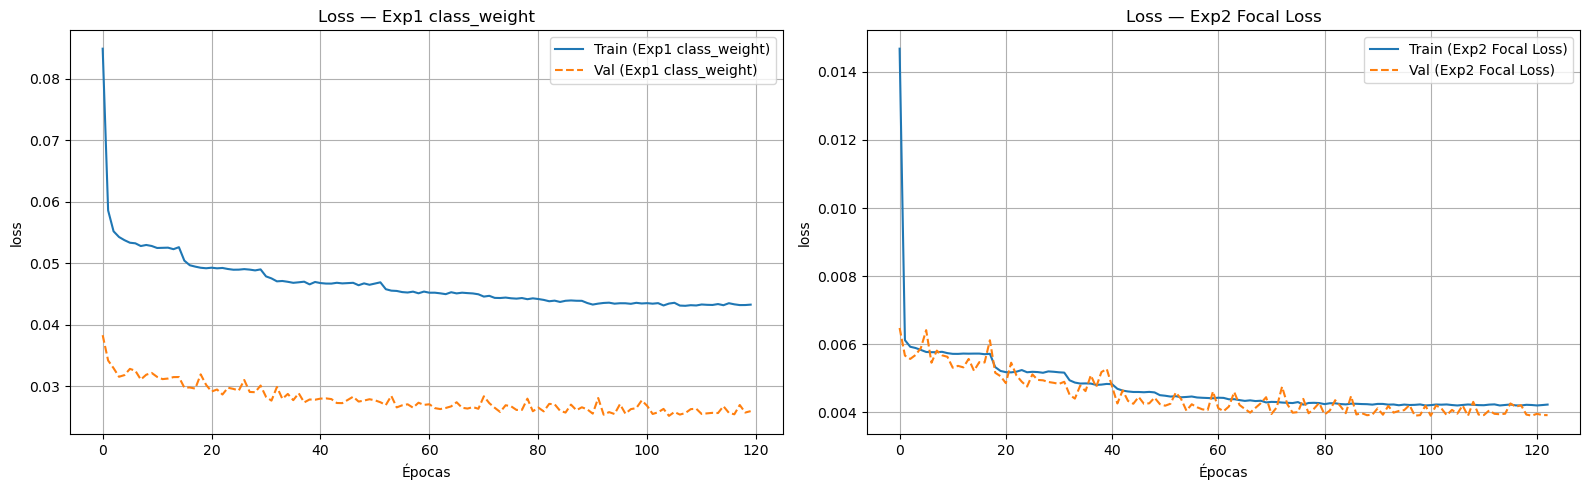

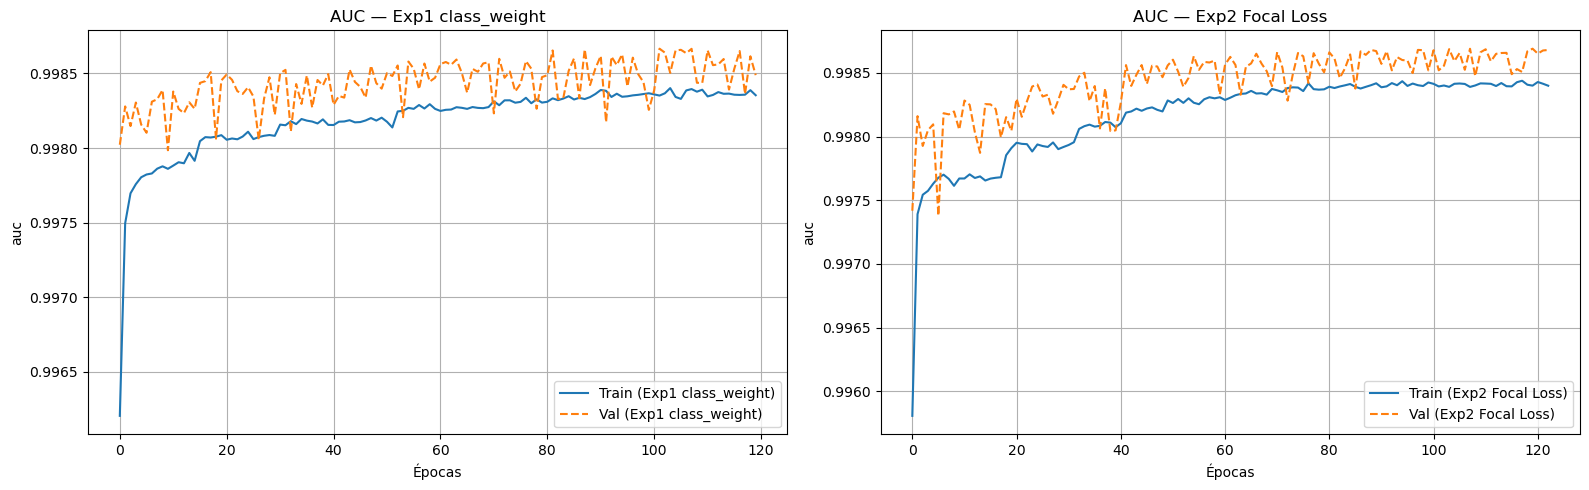

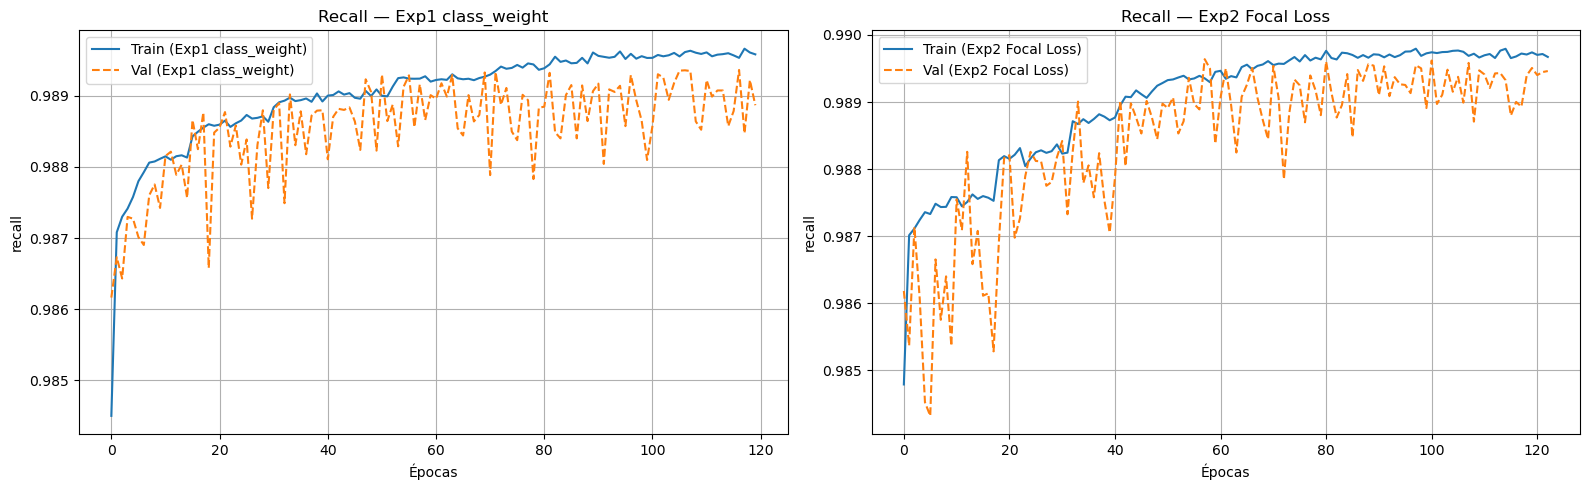

In [ ]:
def plot_history(hist1, metric, title):
    fig, axes = plt.subplots(1, 1, figsize=(16, 5))
    for ax, hist, label in zip(axes, [hist1], ['Focal Loss']):
        ax.plot(hist.history[metric],     label=f'Train ({label})')
        ax.plot(hist.history[f'val_{metric}'], label=f'Val ({label})', linestyle='--')
        ax.set_title(f'{title} — {label}')
        ax.set_xlabel('Épocas'); ax.set_ylabel(metric)
        ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

plot_history(history_model_v3, 'loss', 'Loss')
plot_history(history_model_v3, 'auc',  'AUC')
plot_history(history_model_v3, 'recall', 'Recall')


In [ ]:
def evaluate_model(model, X, y, name, batch_size=BATCH_SIZE):
    print(f'\n=== {name} ===')
    res = model.evaluate(X, y, batch_size=batch_size, verbose=0)
    for n, v in zip(model.metrics_names, res):
        print(f'  {n}: {v:.4f}')
    probs = model.predict(X, batch_size=batch_size)
    preds = (probs > 0.5).astype(int)
    print(classification_report(y, preds,
          target_names=['Legítimo (0)', 'Malicioso (1)'], digits=4))
    return probs

probs_exp2 = evaluate_model(model_v3, X_test, y_test, 'EXP2 (Focal Loss)  — Test Interno')



=== EXP1 (class_weight) — Test Interno ===
  loss: 0.0257
  accuracy: 0.9943
  precision: 0.9995
  recall: 0.9890
  auc: 0.9985
1545/1545 [==============================] - 2s 1ms/step
               precision    recall  f1-score   support

 Legítimo (0)     0.9891    0.9995    0.9943     98838
Malicioso (1)     0.9995    0.9890    0.9942     98838

     accuracy                         0.9943    197676
    macro avg     0.9943    0.9943    0.9943    197676
 weighted avg     0.9943    0.9943    0.9943    197676


=== EXP2 (Focal Loss)  — Test Interno ===
  loss: 0.0040
  accuracy: 0.9940
  precision: 0.9986
  recall: 0.9894
  auc: 0.9986
1545/1545 [==============================] - 2s 1ms/step
               precision    recall  f1-score   support

 Legítimo (0)     0.9895    0.9987    0.9941     98838
Malicioso (1)     0.9986    0.9894    0.9940     98838

     accuracy                         0.9940    197676
    macro avg     0.9941    0.9940    0.9940    197676
 weighted avg     0

In [ ]:
def find_optimal_threshold(y_true, y_pred_probs, label='Modelo'):
    """Devuelve (threshold_f1, threshold_recall99) y plotea la curva PR."""
    prec, rec, thr = precision_recall_curve(y_true, y_pred_probs)

    # Umbral que maximiza F1
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    idx_f1 = np.argmax(f1)
    thr_f1 = thr[min(idx_f1, len(thr)-1)]

    # Umbral con recall >= 99%  y máxima precision
    valid = rec >= 0.99
    p_valid = np.where(valid, prec, 0)
    idx_r99 = np.argmax(p_valid)
    thr_r99 = thr[min(idx_r99, len(thr)-1)]

    print(f'[{label}] Umbral F1-max  : {thr_f1:.4f}  →  P={prec[idx_f1]:.4f}  R={rec[idx_f1]:.4f}  F1={f1[idx_f1]:.4f}')
    print(f'[{label}] Umbral R>=99%  : {thr_r99:.4f}  →  P={prec[idx_r99]:.4f}  R={rec[idx_r99]:.4f}')

    plt.figure(figsize=(9, 5))
    plt.plot(rec, prec, label=f'PR Curve — {label}')
    plt.axhline(0.99, color='r', ls='--', alpha=.6, label='Precision 99%')
    plt.axvline(0.99, color='g', ls='--', alpha=.6, label='Recall 99%')
    plt.scatter([rec[idx_f1]], [prec[idx_f1]], color='blue',  zorder=5, label=f'F1-max ({thr_f1:.3f})')
    plt.scatter([rec[idx_r99]], [prec[idx_r99]], color='orange', zorder=5, label=f'R>=99% ({thr_r99:.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'Curva Precision-Recall — {label}')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    return thr_f1, thr_r99

thr2_f1, thr2_r99 = find_optimal_threshold(y_test, probs_exp2, 'Exp2 Focal Loss')


In [ ]:
def eval_with_threshold(y_true, probs, threshold, label):
    preds = (probs > threshold).astype(int)
    print(f'\n=== {label} (thr={threshold:.4f}) ===')
    print(classification_report(y_true, preds,
          target_names=['Legítimo (0)', 'Malicioso (1)'], digits=4))
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legítimo', 'Malicioso'])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(label); plt.tight_layout(); plt.show()

# Exp2 — umbral optimizado
eval_with_threshold(y_test, probs_exp2, thr2_r99, 'Exp2 Focal Loss — R>=99%')


In [ ]:
# ═══════════════════════════════════════════════════════
# EVALUACIÓN FINAL — Holdout de tráfico real (10% original)
# Distribución natural desbalanceada: más representativa de producción
# ═══════════════════════════════════════════════════════

df_holdout = pd.read_feather('test_real_traffic.feather')
df_holdout = df_holdout.replace([np.inf, -np.inf], np.nan)\
                        .dropna(subset=FEATURES_SELECCIONADAS + ['label'])

y_holdout = (df_holdout['label'] != NOMBRE_CLASE_BENIGNA).astype(int).values
X_holdout = scaler.transform(df_holdout[FEATURES_SELECCIONADAS].values)

print(f'Holdout — Total: {len(y_holdout):,}')
print(f'  Benigno   : {(y_holdout==0).sum():,} ({(y_holdout==0).mean():.2%})')
print(f'  Malicioso : {(y_holdout==1).sum():,} ({(y_holdout==1).mean():.2%})')

probs_h2 = model_v3.predict(X_holdout, batch_size=BATCH_SIZE)

# Umbral 0.5 (default)
eval_with_threshold(y_holdout, probs_h2, 0.5,    'Holdout — Exp2 umbral 0.5')

# Umbral optimizado (recall >= 99%)
eval_with_threshold(y_holdout, probs_h2, thr2_r99, f'Holdout — Exp2 umbral {thr2_r99:.4f}')


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

def summary_row(name, y_true, probs, threshold):
    preds = (probs > threshold).astype(int)
    return {
        'Modelo': name,
        'Umbral': round(threshold, 4),
        'Accuracy': round(accuracy_score(y_true, preds), 4),
        'Precision (mal)': round(precision_score(y_true, preds), 4),
        'Recall (mal)':    round(recall_score(y_true, preds), 4),
        'F1 (mal)':        round(f1_score(y_true, preds), 4),
        'AUC-ROC':         round(roc_auc_score(y_true, probs), 4),
    }

rows = [
    summary_row('Exp2 Focal Loss    (thr=0.50)', y_holdout, probs_h2, 0.5),
    summary_row('Exp2 Focal Loss    (thr=R99%)', y_holdout, probs_h2, thr2_r99),
]

df_results = pd.DataFrame(rows)
print('\n=== TABLA COMPARATIVA HOLDOUT TRÁFICO REAL ===')
print(df_results.to_string(index=False))
df_results.to_csv('comparativa_experimentos.csv', index=False)
print('\nGuardada en comparativa_experimentos.csv')



=== TABLA COMPARATIVA HOLDOUT TRÁFICO REAL ===
                       Modelo  Umbral  Accuracy  Precision (mal)  Recall (mal)  F1 (mal)  AUC-ROC
Exp1 class_weight  (thr=0.50)  0.5000    0.9893           1.0000        0.9890    0.9945   0.9987
Exp1 class_weight  (thr=R99%)  0.2937    0.9903           1.0000        0.9901    0.9950   0.9987
Exp2 Focal Loss    (thr=0.50)  0.5000    0.9897           1.0000        0.9895    0.9947   0.9986
Exp2 Focal Loss    (thr=R99%)  0.4523    0.9903           0.9999        0.9902    0.9950   0.9986

Guardada en comparativa_experimentos.csv


In [ ]:
# Guardar ambos modelos finales y el scaler compartido
model_v3.save('mlp_binario_v3_focalloss.h5')
joblib.dump(scaler, 'standard_scaler_binario_v3.pkl')

Modelos, scaler y umbrales guardados.
{
  "exp1_f1": 0.3850601613521576,
  "exp1_r99": 0.2936955690383911,
  "exp2_f1": 0.5282748341560364,
  "exp2_r99": 0.45225340127944946
}
